## Examples for using SimSuite

Yair Franco, 2026

In [1]:
import simsuite as ss
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

SimSuite is useful for processing SeisSol outputs as a single object. Once a SeisSol output folder is initialized with ```ss.SeisSolOutput()```, it's easy to run the different functionality without having to re-read it.

In [2]:
# define file output prefix, which all SeisSol outputs from the same simulation share
p = 'tpv10t_d60'
fpath = f"./{p}/{p}-surface.xdmf"

# Instantiate mesh data as a SimSuite object to run functions on it
mesh_data = ss.SeisSolOutput(p)

I've written a few functions for my purposes that help extract the mesh data for plotting with PyVista.

Here, I plot the 'v2' component of ground velocity 10 seconds into a SeisSol simulation.

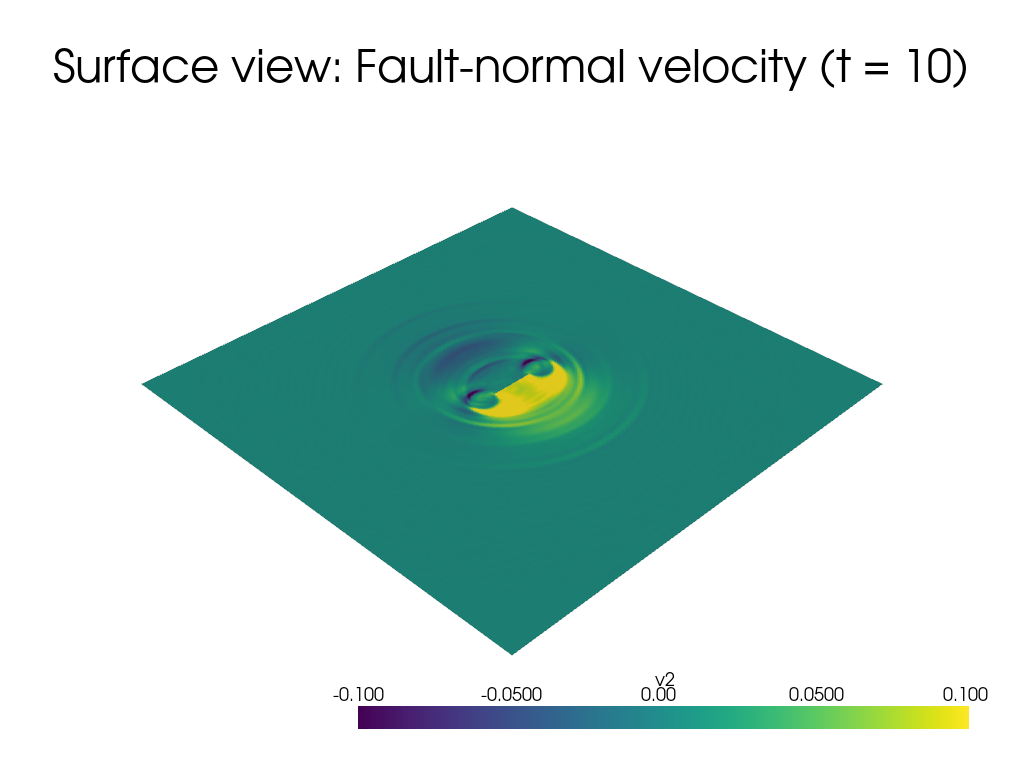

In [3]:
# The surface mesh is loaded at a specified time t
t = 10
surface_mesh = mesh_data.load_surface_mesh(t)
surface_mesh.set_active_scalars("v2")


# Initialize a PyVista plotter
p = pv.Plotter()
# Add the mesh data to the plotter
p.add_mesh(surface_mesh,scalars="v2",clim=[-0.1,0.1])

p.add_title(f"Surface view: Fault-normal velocity (t = {t})")

# Show plot
p.show(jupyter_backend="static")

It can also be used to plot the fault mesh.

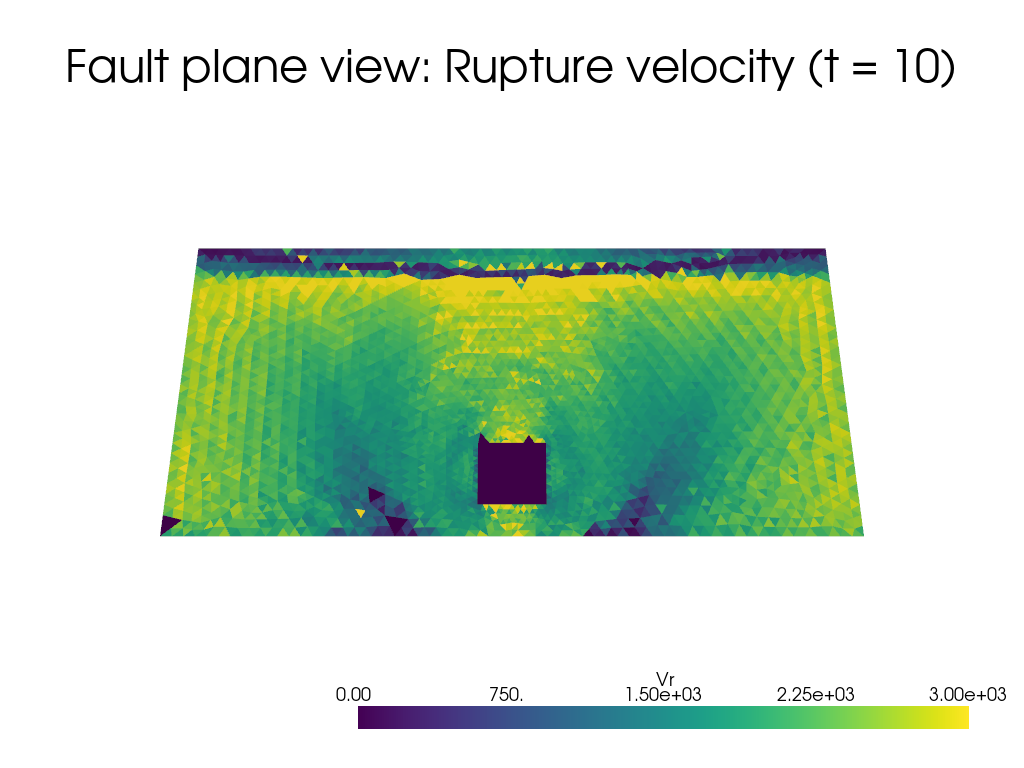

In [4]:
# Same as before, but for the fault data
t = 10
fault_mesh = mesh_data.load_fault_mesh(t)
fault_mesh.set_active_scalars("Vr")

p = pv.Plotter()
p.add_mesh(fault_mesh,clim=[0,3000])
p.add_title(f"Fault plane view: Rupture velocity (t = {t})")

#Re-orient camera to show fault plane view
p.camera_position = 'xz'

# Show plot
p.show(jupyter_backend="static")

SeisSol also outputs moment release data as a CSV file. SimSuite can get useful parameters from this CSV.

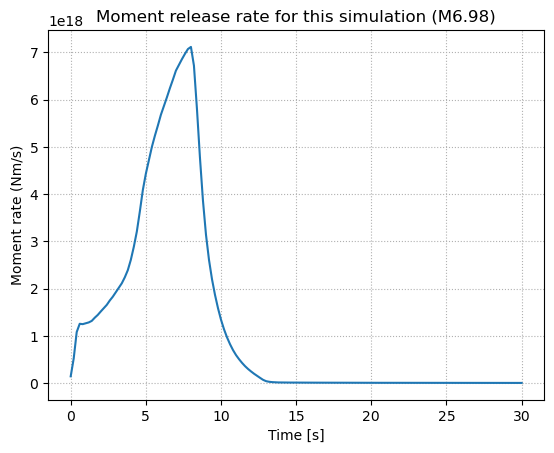

In [5]:
# Get moment magnitude from moment at last time step in simulation
seis_mag = mesh_data.get_mw()
# Get moment vs. time data
times, moments, rates = mesh_data.get_moment()

plt.plot(times, rates)
plt.title(f"Moment release rate for this simulation (M{seis_mag})")
plt.xlabel("Time [s]")
plt.ylabel("Moment rate (Nm/s)")
plt.grid(ls=":");

SimSuite can also get the RotD50 ground motion metric for comparison to ground motion models (GMMs).

In [6]:
# Get peak ground motion for all cells in the mesh
# print_status helps track progress as this processing takes some time
mesh_pgv = mesh_data.get_pgv_rotd50(print_status=True)

Getting PGV Rotd50 for simulation tpv10t_d60.                                 Time step 30.0/30.0.                                 Iteration time: 0.061 s
Execution time: 17.551 s


The calculated data can then be added to the mesh for plotting.

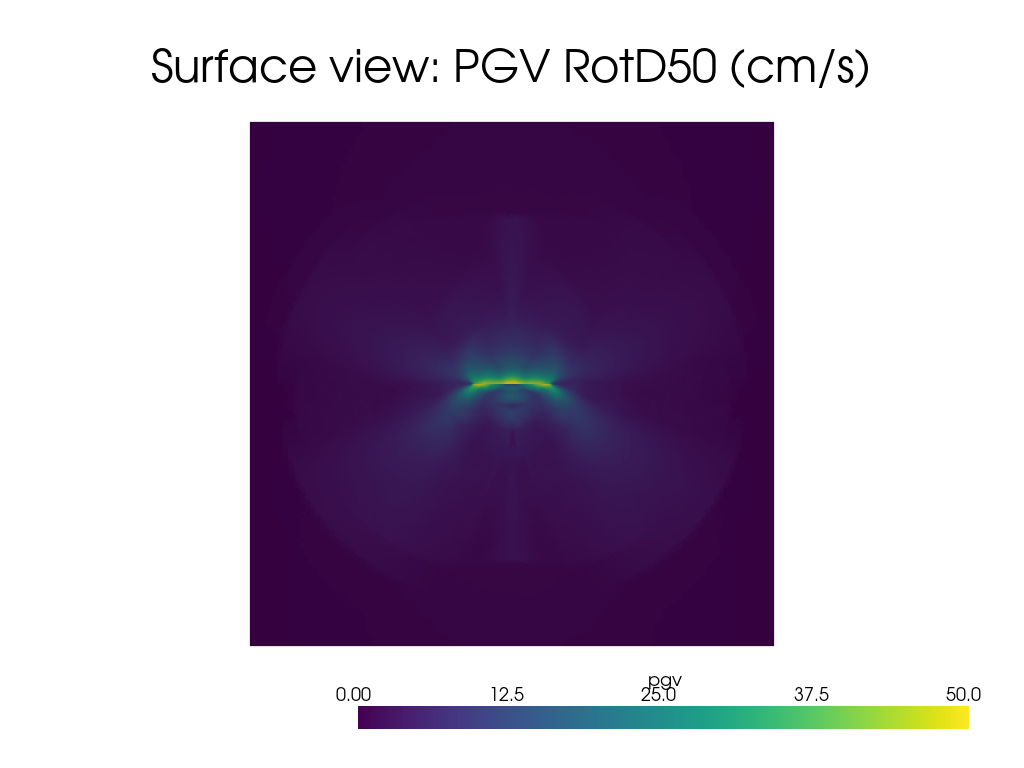

In [7]:
# PyVista provides functions to add this data to the mesh
surface_mesh.cell_data.set_array(mesh_pgv*100,'pgv') # times 100 to convert to cm/s (this is the more conventional unit)
surface_mesh.cell_data.active_scalars_name = 'pgv'

p = pv.Plotter()
p.add_mesh(surface_mesh,scalars='pgv',clim=[0,50])
p.add_title(f"Surface view: PGV RotD50 (cm/s)")

p.camera_position = 'xy'

p.show(jupyter_backend="static")

With the loaded surface mesh, it is easy to obtain the coordinates for the center of each cell for GMM calculations requiring destance metrics.

In [8]:
mesh_points = surface_mesh.cell_centers().points / 1000 #convert to km for easier reading
print(mesh_points[:5])
print(len(mesh_points), "points in surface mesh")

[[-13.38935264  -1.06637785   0.        ]
 [-13.21102824  -1.51294755   0.        ]
 [-12.8526991   -1.0623647    0.        ]
 [-13.15102666  -1.2138967    0.        ]
 [ -8.37804952  -1.01836777   0.        ]]
32728 points in surface mesh


Using this, we can calculate some of the distance metrics used in GMMs, like $R_{rup}$, which measures the distance from the site to the rupturing fault plane. This kind of calculation gets complicated very quickly, so SimSuite has handler functions for this too.

To do this, we must initialize a Distances object with our fault information. In this example I will try to match the parameters from the simulation we've been looking at.

Distances needs a few attributes, documented here:

In [9]:
help(ss.Distances())

Help on Distances in module simsuite object:

class Distances(builtins.object)
 |  Distances(strike=None, dip=None, fault_length=None, fault_width=None, hyp_depth=None, hyp_along_strike=None, ztor=None)
 |  
 |  Calculators for earthquake-site distance metrics needed for GMMs
 |  
 |  **These calculations assume the (n,e,z) point (0,0,0) is the HYPOCENTER.**
 |  
 |  Note this is different to some conventions where the origin is the center of the
 |  top edge of the rupture.
 |  
 |  Algorithms from Baker et al. 'Seismic Hazard and Risk Analysis' (2021) Chapter 3
 |  
 |  Attr:
 |      strike: fault strike [deg]
 |      dip: fault dip [deg]
 |      fault_length: [km]
 |      fault_width: [km]
 |      hyp_depth: hypocentral depth [km]
 |      hyp_along_strike: distance of hypocenter along strike [km]
 |      ztor: depth of top edge of rupture [km]
 |  
 |  Args for calc_ functions:
 |      points: site where GMM is calculated [(n,3) array of (x,y,z) coords]
 |      convert_xyz: whether 

In [10]:
d = ss.Distances(
    strike=0,
    dip=60,
    fault_length=30,
    fault_width=15,
    hyp_depth=12,
    hyp_along_strike=15,
    ztor=0
)

This object can now handle all the distance functions we need for GMM calculations.

This is a plot of $R_{jb}$, the distance to the surface fault projection. It is equal to 0 at any surface point directly above the fault plane (dark purple in this plot).

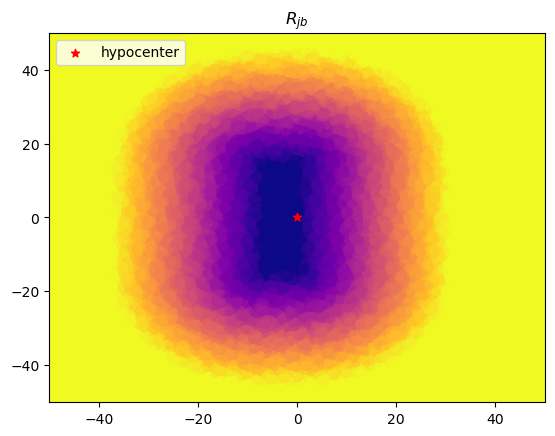

In [11]:
rjbs = d.calc_Rjb(mesh_points)
rrups = d.calc_Rrup(mesh_points)
x, y = mesh_points[:,0], mesh_points[:,1]

plt.scatter(x,y,c=rjbs,cmap='plasma',vmax=30)
plt.scatter(0,0,marker="*",c='r',label='hypocenter')
plt.title("$R_{jb}$")
plt.xlim(-50,50)
plt.ylim(-50,50)
plt.legend();

All of these functions working in tandem can be used to calculate GMM predictions for the scenario we've been working on.

The function ```OpenquakeACScenario()``` will use the Distances and SeisSolOutput objects containing the needed info (in addition to a few extra parameters) to calculate the ground motion predictions for the scenario defined in the objects. It uses OpenQuake to get the GMM data, and the output is the average of the GMMs. The ones used in this function are the Active Crustal GMMs, which are used in seismic hazard models.

In [16]:
ac, _ = ss.OpenquakeACScenario('normal',d,mesh_data)

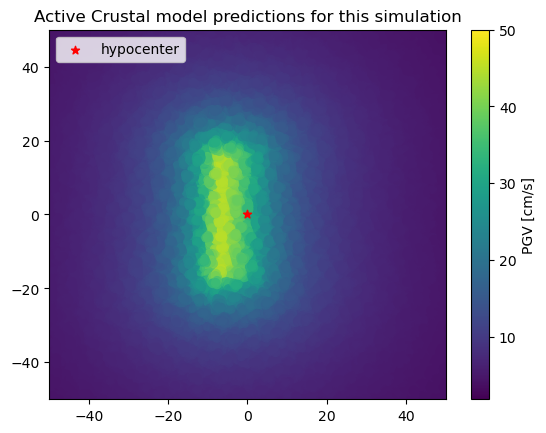

In [21]:
plt.scatter(x,y,c=ac,vmax=50)
plt.colorbar(label="PGV [cm/s]")

plt.scatter(0,0,marker="*",c='r',label='hypocenter')

plt.title("Active Crustal model predictions for this simulation")
plt.xlim(-50,50)
plt.ylim(-50,50)
plt.legend();

Additionally, SimSuite is useful for calculating certain simulation parameters, like material properties.

The Materials class helps get ground velocities based on physical parameters like density and shear modulus. This is particularly useful for getting a sense of the velocity model in a simulation, where the properties are defined purely by these parameters, and they are not easy to calculate manually.

In this example, note what happens when we try to calculate velocities by giving two parameters.

In [35]:
material = ss.Materials(
    mu = 3.2038e10,
    rho = 2670
)
vs = material.get_Vs()
print(f"Shear wave velocity for defined parameters: {round(vs,2)} m/s")

vp = material.get_Vp()

Shear wave velocity for defined parameters: 3463.99 m/s


ValueError: Missing required properties: K

We get an error because the p-wave speed also depends on the bulk modulus K. Since it gives a warning for missing parameters, this function is also useful for determining which parameters are needed for SeisSol to run properly.

In [37]:
# define K for 'material'
material.K = 1.6e10
# the get_Vp function works now
material.get_Vp()

4689.510700673934